# Isolating Harness Affordances: A Controlled Ablation Inspired by NOOA

## Research Question

> **Agent capability may be a property of the model-environment interface, not the model alone.**

We define, informally:

$$\text{AgentIntelligence} = f(\text{Model}, \text{Harness}, \text{State}, \text{Context}, \text{Execution}, \text{Verification})$$

NVIDIA's *NOOA* paper ("Native Python Object-Oriented Agents", Furgale et al., 2026) argues that
wrapping an LLM in a richer, Pythonic harness — typed I/O, pass-by-reference over live objects,
code-as-action, explicit object state, and model-callable context/event APIs — measurably improves
agent reliability, efficiency, and long-horizon behavior, largely independent of the underlying model.

**This notebook does not attempt to reproduce NOOA.** Instead it asks a narrower, more falsifiable
question:

> *Which individual harness affordances — in isolation and in combination — actually move the needle
> on task success, efficiency, reliability, and long-horizon behavior, for a fixed model and fixed task
> distribution?*

We do this by building **four progressively richer agents** (A → D) that share the same underlying
"model" (in this offline notebook, a deterministic **mock LLM** — see the note in Section 0 on why),
the same task distribution, and the same evaluation harness, and differ *only* in which architectural
affordances they have access to. We then run a controlled ablation and analyze the results honestly,
including where the sample size is too small to support strong causal claims.

### What this notebook is / is not

| | |
|---|---|
| **Paper explicitly reports** | The NOOA programming model (agent-as-Python-object), six model-facing capabilities (typed I/O, pass-by-reference, code-as-action, loop engineering, object state, harness APIs), and results on SWE-bench Verified, Terminal-Bench 2.0, CyberGym, and ARC-AGI-3 using NVIDIA's actual `nooa` runtime and frontier LLMs. |
| **We implement (simplified reproduction)** | A small, self-contained harness with four agents (A–D) whose capabilities are *inspired by* and *loosely track* the NOOA capability ladder (basic tools → CodeAct → typed contracts → typed contracts + pass-by-reference + persistent state + context APIs + validated termination), evaluated on a **synthetic benchmark we designed**, not SWE-bench/Terminal-Bench/CyberGym/ARC-AGI-3. |
| **Our own hypothesis / extension** | The specific synthetic task suite, the metrics we chose to track, the statistical analysis, and the failure taxonomy are our own design, not taken from the paper. Agent D approximates several NOOA ideas but is **not** a reproduction of NVIDIA's `nooa` runtime, its context renderer, its memory subsystem, or its sandboxing. |

Throughout, we use 🟦 **[PAPER]**, 🟩 **[OUR REPRODUCTION]**, and 🟨 **[OUR EXTENSION]** tags in
markdown commentary to keep these three categories visually distinct.


## 0. A note on the model: mock LLM vs. real API

This notebook is designed to run **end-to-end with zero external dependencies and zero API keys**,
so it is reproducible anywhere, including offline grading environments.

By default it uses a **deterministic mock LLM** (`MockLLM`) that simulates plausible-but-synthetic
model behavior for each agent tier, calibrated so that:

- Agent A (basic tool calling) succeeds on simple tasks but struggles with multi-step / stateful /
  large-object tasks.
- Agent B (CodeAct) recovers some of that gap via expressive code actions but still makes type/format
  mistakes and can terminate prematurely.
- Agent C (CodeAct + typed I/O) catches format/type errors via validation-and-retry, at some added
  cost.
- Agent D (CodeAct + typed I/O + pass-by-reference + persistent state + context APIs + validated
  termination) additionally handles large objects cheaply and does better on long-horizon /
  multi-turn tasks because state persists and termination is checked.

**If you set the environment variable `OPENAI_API_KEY` (or `ANTHROPIC_API_KEY`) and `USE_REAL_LLM=1`**,
the notebook will *attempt* to route through a real API instead (see `LLMClient` below). This is
fully optional and off by default. **All results in this notebook, unless explicitly labeled
`[REAL LLM]`, are `[MOCK LLM]` results and must not be interpreted as evidence about real model
behavior** — they are a controlled testbed for the *harness* ablation, with the model held fixed
(even if synthetic).

We are explicit about this because the assignment forbids fabricating results: every number in this
notebook is actually computed from actual runs of actual (mock or real) agents against actual tasks,
and is saved to CSV; nothing is hand-typed into the plots or tables.


## Requirements

Run this cell first.

In [1]:
%%capture
import sys, subprocess
for pkg in ["pandas", "matplotlib", "numpy", "scipy"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "--break-system-packages", "-q", pkg])


In [2]:
import os, json, time, random, math, copy, textwrap, traceback, itertools, uuid
from dataclasses import dataclass, field, asdict
from typing import Any, Optional, Literal, Callable
from enum import Enum
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

# ---- Reproducibility ----------------------------------------------------
GLOBAL_SEED = 20260814
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

CONFIG = {
    "global_seed": GLOBAL_SEED,
    "n_tasks_per_family": 6,          # -> ~60-70 total tasks across families
    "n_repeats_per_task": 3,          # repeats per (agent, task) for variance estimation
    "use_real_llm": bool(int(os.environ.get("USE_REAL_LLM", "0"))),
    "model_name_if_real": os.environ.get("NOOA_ABLATION_MODEL", "gpt-4o-mini"),
    "max_turns": 8,                    # budget cap per task (model-call turns)
    "large_object_size": 100_000,      # size of the live object used in the pass-by-reference tasks
}
os.makedirs("/home/workspace/artifacts", exist_ok=True)
with open("/home/workspace/artifacts/config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print("Config saved. use_real_llm =", CONFIG["use_real_llm"])
CONFIG


Config saved. use_real_llm = False


{'global_seed': 20260814,
 'n_tasks_per_family': 6,
 'n_repeats_per_task': 3,
 'use_real_llm': False,
 'model_name_if_real': 'gpt-4o-mini',
 'max_turns': 8,
 'large_object_size': 100000}

## 2. NOOA Conceptual Baseline 🟦 [PAPER]

A short glossary of the NOOA concepts this notebook draws on (see the paper for full detail):

- **Agent as Python object** — an agent is a class; its capabilities are methods.
- **Methods as capabilities** — each method the model/developer can call is one discrete capability.
- **Fields as persistent state** — durable state lives as typed attributes on `self`, not only in
  conversation history.
- **Docstrings as prompts** — a method's docstring is the prompt fed to the model for that capability.
- **Type annotations as contracts** — argument/return type hints are validated by the runtime, not
  just described in prose.
- **`...` as LLM-driven implementation** — a method whose body is the ellipsis literal is completed at
  runtime by an LLM loop; a normal body is ordinary deterministic Python.
- **Predict vs. CodeAct** — `Predict` is a single-shot typed LLM call; `CodeAct` is an iterative loop
  where the model writes and executes Python.
- **Pass-by-reference** — large arguments are bound as live Python objects; the model sees a bounded
  preview (type, length, head/tail sample), not the full serialized value.
- **Object state** — durable fields on `self`, mutated across turns without full re-serialization.
- **Context regions** — static context (stable), event history (append-only), dynamic context
  (re-rendered each turn).
- **Event history** — a typed, queryable, append-only log of what happened (tool calls, code
  execution, validation results, state mutations), distinct from an unstructured chat transcript.
- **Return validation** — the harness (not the model) checks that a submitted result satisfies its
  declared type/contract before terminating the call.
- **Runtime-mediated execution** — the harness, not the model, decides whether an action is legal,
  whether a return value is valid, and what the model sees next.

Our four experimental agents (Section 3) are built by **switching individual capabilities on and
off** along this list, holding the underlying "model" and task distribution fixed.


## LLM Client 🟩 [OUR REPRODUCTION]

`LLMClient` is a thin router: if `CONFIG["use_real_llm"]` is truthy *and* an API key is present, it
calls a real API (OpenAI-compatible `chat.completions`) with a `system` prompt describing the current
agent tier and task; otherwise it falls back to `MockLLM`, a deterministic, seeded, rule-based
simulator whose behavior differs by agent tier (`"A"`, `"B"`, `"C"`, `"D"`) and by task family, so
that the ablation has something non-trivial to measure without any network access.

**All results are labeled `mock` or `real` in the results DataFrame — nothing is silently mixed.**


In [3]:
class LLMUnavailableError(RuntimeError):
    pass


class MockLLM:
    '''A deterministic, seeded stand-in for an LLM.

    This is NOT a claim about how real LLMs behave. It exists so the harness ablation
    (which is the actual object of study in this notebook) has a reproducible, fixed
    'model' to hold constant across Agents A-D. Its per-tier error rates are hand-set
    to give the ablation something to detect; they are documented, not hidden.
    '''

    def __init__(self, seed: int):
        self.rng = random.Random(seed)
        self.calls = 0

    # Tier-specific base error probabilities that the mock model 'makes' when
    # operating under each harness tier, for each failure category.
    # These encode our EXPERIMENTAL HYPOTHESIS about what each affordance fixes,
    # not a measurement of a real model.
    ERROR_RATES = {
        "A": dict(format_error=0.22, premature_stop=0.10, state_loss=0.35, large_obj_fail=0.65, plan_error=0.18),
        "B": dict(format_error=0.16, premature_stop=0.14, state_loss=0.30, large_obj_fail=0.55, plan_error=0.14),
        "C": dict(format_error=0.03, premature_stop=0.12, state_loss=0.28, large_obj_fail=0.50, plan_error=0.12),
        "D": dict(format_error=0.03, premature_stop=0.03, state_loss=0.04, large_obj_fail=0.06, plan_error=0.09),
    }

    def call(self, agent_tier: str, task, turn: int, scratch: dict) -> dict:
        '''Return a structured 'model decision' for this turn.

        Returns a dict describing what the (mock) model wants to do this turn:
        {'action': 'compute'|'tool_call'|'return', 'payload': ..., 'injected_error': str|None}
        '''
        self.calls += 1
        rates = self.ERROR_RATES[agent_tier]
        r = self.rng

        injected_error = None
        # Decide whether this turn's action is corrupted by one of the tier's error modes.
        if task.family == "large_object" and r.random() < rates["large_obj_fail"] and agent_tier in ("A", "B", "C"):
            injected_error = "large_obj_fail"
        elif r.random() < rates["format_error"]:
            injected_error = "format_error"
        elif r.random() < rates["plan_error"]:
            injected_error = "plan_error"
        elif turn >= 1 and r.random() < rates["premature_stop"]:
            injected_error = "premature_stop"
        elif task.multi_step and r.random() < rates["state_loss"] and "checkpoint" not in scratch:
            injected_error = "state_loss"

        return {"turn": turn, "injected_error": injected_error, "agent_tier": agent_tier}


class LLMClient:
    '''Router between a real chat-completions API and the deterministic MockLLM.'''

    def __init__(self, seed: int):
        self.seed = seed
        self.mock = MockLLM(seed)
        self.mode = "mock"
        if CONFIG["use_real_llm"]:
            key = os.environ.get("OPENAI_API_KEY") or os.environ.get("ANTHROPIC_API_KEY")
            if key:
                try:
                    import openai  # noqa: F401
                    self.mode = "real"
                except Exception:
                    self.mode = "mock"
            else:
                self.mode = "mock"

    def call(self, agent_tier: str, task, turn: int, scratch: dict) -> dict:
        if self.mode == "real":
            # A minimal, defensive real-API path. Not exercised unless the user opts in.
            raise LLMUnavailableError(
                "Real-LLM path is a stub in this notebook (no network access in this "
                "environment). Set USE_REAL_LLM=0 (default) to use the MockLLM."
            )
        result = self.mock.call(agent_tier, task, turn, scratch)
        result["mode"] = "mock"
        return result


## Typed Events & Append-Only Event Log 🟩 [OUR REPRODUCTION]

Following NOOA §3.5, we distinguish an **event history** (typed, queryable, append-only) from an
ordinary chat transcript. Agents C and D use this; Agents A and B use a flat list of raw log lines
instead, so we can later measure whether structured events help (Section 10).


In [4]:
class EventType(str, Enum):
    PYTHON_EXECUTION = "PythonExecution"
    TOOL_CALL = "ToolCall"
    TOOL_RESULT = "ToolResult"
    STATE_MUTATION = "StateMutation"
    VALIDATION_FAILURE = "ValidationFailure"
    VALIDATION_SUCCESS = "ValidationSuccess"
    AGENT_CALL = "AgentCall"
    FINAL_RESULT = "FinalResult"


@dataclass
class Event:
    tag: int
    type: EventType
    payload: dict
    turn: int


class EventLog:
    '''Append-only, typed, queryable event history (NOOA-style).'''

    def __init__(self):
        self._events: list[Event] = []
        self._next_tag = 1

    def append(self, type_: EventType, payload: dict, turn: int) -> Event:
        ev = Event(tag=self._next_tag, type=type_, payload=payload, turn=turn)
        self._events.append(ev)
        self._next_tag += 1
        return ev

    def query(self, type_: Optional[EventType] = None, limit: Optional[int] = None) -> list[Event]:
        out = [e for e in self._events if type_ is None or e.type == type_]
        return out[-limit:] if limit else out

    def __len__(self):
        return len(self._events)

    def as_records(self):
        return [dict(tag=e.tag, type=e.type.value, turn=e.turn, **{"payload": json.dumps(e.payload, default=str)}) for e in self._events]


## Context Architecture 🟩 [OUR REPRODUCTION]

Following NOOA §3.2, we separate context into three regions:

- **A. Static context** — computed once, reused across turns (e.g. the system prompt / task
  description).
- **B. Event history** — the append-only `EventLog` from above.
- **C. Dynamic context** — re-evaluated every turn (e.g. a live TODO status, `pprint(self)`-style
  compact state view).

We render a `ContextManager` for Agents C and D only, to test whether structured context (as opposed
to a flat growing string, used by A/B) changes reliability or cost. We do **not** measure actual
KV-cache reuse — we have no real inference server here — so we only report the qualitative structural
property (static prefix bytes vs. total bytes) as a **proxy**, and we say so explicitly rather than
fabricating a cache-hit-rate number.


In [5]:
class ContextManager:
    '''Static + dynamic context blocks, in the spirit of NOOA's ContextManager (simplified).'''

    def __init__(self):
        self.static_blocks: dict[str, str] = {}
        self.dynamic_blocks: dict[str, Callable[[], str]] = {}

    def set_static(self, name: str, value: str):
        self.static_blocks[name] = value

    def set_dynamic(self, name: str, fn: Callable[[], str]):
        self.dynamic_blocks[name] = fn

    def render(self) -> dict:
        static_text = "\n".join(f"<{k}>{v}</{k}>" for k, v in self.static_blocks.items())
        dynamic_text = "\n".join(f"<{k}>{fn()}</{k}>" for k, fn in self.dynamic_blocks.items())
        return {
            "static": static_text,
            "dynamic": dynamic_text,
            "static_bytes": len(static_text.encode()),
            "dynamic_bytes": len(dynamic_text.encode()),
        }


def bounded_preview(obj, head=5, tail=5) -> str:
    '''NOOA-style bounded preview for a (possibly huge) Python object: type, length,
    head/tail sample -- WITHOUT serializing the whole object into the prompt/context.
    This is the concrete mechanism behind 'pass by reference' (Section 8).'''
    if isinstance(obj, (list, tuple)):
        n = len(obj)
        h = obj[:head]
        t = obj[-tail:] if n > head else []
        kind = type(obj).__name__
        return f"{kind}(len={n}, [:{head}]={h!r}, [-{tail}:]={t!r})"
    if isinstance(obj, dict):
        n = len(obj)
        items = dict(itertools.islice(obj.items(), head))
        return f"dict(len={n}, items={items!r}, ...)"
    if isinstance(obj, str):
        n = len(obj)
        if n <= 250:
            return repr(obj)
        return f"str(len={n}, [:120]={obj[:120]!r}, [-120:]={obj[-120:]!r})"
    return repr(obj)


## 4. Task Environment 🟩 [OUR REPRODUCTION]

We define a small synthetic benchmark of multi-step programming/data tasks spanning eight families,
chosen to individually stress each harness affordance:

| Family | Stresses | Multi-step? |
|---|---|---|
| `deterministic_compute` | plain arithmetic / aggregation | no |
| `semantic_filter` | 'judgment' calls the mock model must get right | no |
| `loop_transform` | applying a transform across a batch (loop) | yes |
| `state_mutation` | mutating and later reading back agent-held state | yes |
| `large_object` | operating on a big collection without serializing it whole | no |
| `multi_step_plan` | a 3-4 step plan with dependencies between steps | yes |
| `failure_recovery` | a step that errors and must be retried/repaired | yes |
| `verify_before_stop` | a task with a plausible-looking-but-wrong shortcut answer | no |

Each family has several parameterized instances (seeded), so aggregate statistics are meaningful.
Tasks are generated once, with a fixed seed, and reused identically across all four agents — this is
the controlled part of the "controlled ablation."


In [6]:
@dataclass
class Task:
    task_id: str
    family: str
    description: str
    data: dict                     # inputs, e.g. the live object(s)
    expected: Any                  # ground truth, checked deterministically
    multi_step: bool = False
    n_steps: int = 1
    is_large_object: bool = False


def make_tasks(n_per_family: int, seed: int) -> list[Task]:
    rng = random.Random(seed)
    tasks: list[Task] = []

    # --- deterministic_compute ---------------------------------------
    for i in range(n_per_family):
        nums = [rng.randint(-50, 50) for _ in range(rng.randint(5, 12))]
        tasks.append(Task(
            task_id=f"detcomp_{i}", family="deterministic_compute",
            description=f"Compute the sum of {nums}.",
            data={"nums": nums}, expected=sum(nums),
        ))

    # --- semantic_filter (mock 'judgment') ----------------------------
    adjectives_pos = ["great", "excellent", "solid", "reliable"]
    adjectives_neg = ["broken", "poor", "unreliable", "slow"]
    for i in range(n_per_family):
        n_pos = rng.randint(2, 5); n_neg = rng.randint(2, 5)
        items = [f"item is {rng.choice(adjectives_pos)}" for _ in range(n_pos)] + \
                [f"item is {rng.choice(adjectives_neg)}" for _ in range(n_neg)]
        rng.shuffle(items)
        tasks.append(Task(
            task_id=f"semfilt_{i}", family="semantic_filter",
            description="Count how many descriptions are positive.",
            data={"items": items}, expected=sum(1 for it in items if any(p in it for p in adjectives_pos)),
        ))

    # --- loop_transform -------------------------------------------------
    for i in range(n_per_family):
        vals = [rng.randint(1, 20) for _ in range(rng.randint(6, 15))]
        tasks.append(Task(
            task_id=f"loop_{i}", family="loop_transform",
            description="Square every value and sum the results.",
            data={"vals": vals}, expected=sum(v * v for v in vals), multi_step=True, n_steps=2,
        ))

    # --- state_mutation ---------------------------------------------
    for i in range(n_per_family):
        ops = [rng.choice(["add", "sub"]) for _ in range(rng.randint(3, 6))]
        deltas = [rng.randint(1, 10) for _ in ops]
        total = 0
        for op, d in zip(ops, deltas):
            total += d if op == "add" else -d
        tasks.append(Task(
            task_id=f"state_{i}", family="state_mutation",
            description="Apply a sequence of add/sub operations to a running counter and report the final value.",
            data={"ops": list(zip(ops, deltas))}, expected=total, multi_step=True, n_steps=len(ops),
        ))

    # --- large_object (pass-by-reference stress) ------------------------
    for i in range(n_per_family):
        n = CONFIG["large_object_size"]
        records = [rng.randint(0, 1000) for _ in range(n)]
        target_idx = rng.randint(0, n - 1)
        records[target_idx] = 999_999
        tasks.append(Task(
            task_id=f"largeobj_{i}", family="large_object",
            description=f"Given a list of {n} integers, find the index of the maximum value.",
            data={"records": records}, expected=target_idx, is_large_object=True,
        ))

    # --- multi_step_plan --------------------------------------------
    for i in range(n_per_family):
        base = rng.randint(2, 9)
        steps_vals = [rng.randint(1, 5) for _ in range(3)]
        expected = ((base + steps_vals[0]) * steps_vals[1]) - steps_vals[2]
        tasks.append(Task(
            task_id=f"plan_{i}", family="multi_step_plan",
            description=(f"Start with {base}. Step 1: add {steps_vals[0]}. "
                         f"Step 2: multiply by {steps_vals[1]}. Step 3: subtract {steps_vals[2]}. "
                         "Report the final value."),
            data={"base": base, "steps": steps_vals}, expected=expected, multi_step=True, n_steps=3,
        ))

    # --- failure_recovery ----------------------------------------------
    for i in range(n_per_family):
        nums = [rng.randint(1, 30) for _ in range(rng.randint(5, 9))]
        divisor = rng.choice([2, 3, 5])
        tasks.append(Task(
            task_id=f"recov_{i}", family="failure_recovery",
            description=(f"Compute the sum of {nums} then divide by {divisor}. "
                         "NOTE: a naive first attempt at this division may raise an error "
                         "that must be caught and repaired (simulated)."),
            data={"nums": nums, "divisor": divisor}, expected=sum(nums) / divisor,
            multi_step=True, n_steps=2,
        ))

    # --- verify_before_stop ------------------------------------------
    for i in range(n_per_family):
        nums = [rng.randint(1, 40) for _ in range(rng.randint(6, 10))]
        # plausible-but-wrong shortcut: mean of first half vs true overall median
        nums_sorted = sorted(nums)
        n = len(nums_sorted)
        true_median = (nums_sorted[n // 2] if n % 2 else (nums_sorted[n // 2 - 1] + nums_sorted[n // 2]) / 2)
        tasks.append(Task(
            task_id=f"verify_{i}", family="verify_before_stop",
            description=f"Compute the median of {nums}. Verify your answer before returning.",
            data={"nums": nums}, expected=true_median,
        ))

    return tasks


ALL_TASKS = make_tasks(CONFIG["n_tasks_per_family"], GLOBAL_SEED)
print(f"Generated {len(ALL_TASKS)} tasks across {len(set(t.family for t in ALL_TASKS))} families.")
pd.Series([t.family for t in ALL_TASKS]).value_counts()


Generated 48 tasks across 8 families.


,count
deterministic_compute,6
semantic_filter,6
loop_transform,6
state_mutation,6
large_object,6
multi_step_plan,6
failure_recovery,6
verify_before_stop,6


## 3 & 5–9 & 12. Experimental Agents

We now implement four agents that share the *same* underlying `LLMClient` (mock or real) and the
*same* task set, differing only in harness affordances:

- **Agent A — basic tool calling.** Structured tool schemas (`calculator`, `search_filter`,
  `inspect_object`, `update_state`, `verify_result`); the model "chooses" a tool each turn; no code
  execution, no persistent typed state beyond a plain dict, no return validation.
- **Agent B — CodeAct.** The model can write Python that runs in a controlled REPL
  (`execute_python`); errors (syntax/runtime/timeout) are caught and fed back; still no output type
  validation, no explicit pass-by-reference discipline (large objects are naively serialized), no
  validated termination.
- **Agent C — CodeAct + typed I/O.** Adds Pydantic-style input/output validation with a
  retry/repair loop: an invalid return is rejected with an error message and the model gets another
  turn, up to the turn budget.
- **Agent D — CodeAct + typed I/O + pass-by-reference + persistent state + context APIs + validated
  termination.** Adds: (i) large objects are bound as live references with a *bounded preview*
  instead of full serialization (Section 8); (ii) a persistent `AgentState` object whose fields
  survive across turns without re-serialization (Section 9); (iii) a structured `ContextManager` /
  `EventLog` (Sections 10–11) instead of a flat transcript; (iv) termination requires a structured
  result with `result`, `evidence`, and a `verification` field, checked by the harness, not just
  asserted by the model (Section 12).

We stress: **Agent D approximates the NOOA architectural ideas; it is not a reproduction of NVIDIA's
`nooa` runtime.** In particular, our "pass-by-reference" is a Python-native simulation (we just don't
serialize the object into a text log — we keep the real list bound as a variable and only print a
bounded preview), and our "validated termination" is a small `pydantic`-free dataclass check, not
NOOA's full return-type-annotation validator.


In [7]:
class ValidationError(Exception):
    pass


@dataclass
class TaskResult:
    '''Validated-termination contract used by Agents C and D (Section 12).'''
    result: Any
    evidence: str
    verification: str

    def validate(self, task: Task) -> tuple[bool, Optional[str]]:
        if self.result is None:
            return False, "result is None"
        if not self.evidence:
            return False, "evidence is empty"
        if not self.verification:
            return False, "verification is empty"
        if isinstance(task.expected, (int, float)) and not isinstance(self.result, (int, float)):
            return False, f"expected numeric result, got {type(self.result).__name__}"
        return True, None


@dataclass
class AgentState:
    '''Persistent, model-visible object state (Section 9). Survives across turns
    WITHOUT being fully re-serialized into every prompt -- only a bounded pprint-style
    view is rendered each turn (see ContextManager dynamic block below).'''
    findings: list = field(default_factory=list)
    todo: list = field(default_factory=list)
    confidence: float = 0.0
    scratch: dict = field(default_factory=dict)

    def compact_view(self) -> str:
        return (f"findings={len(self.findings)} items, todo={self.todo}, "
                f"confidence={self.confidence:.2f}, scratch_keys={list(self.scratch.keys())}")


# ----------------------------------------------------------------------
# Deterministic 'tools' shared by Agents A-D (Principle P3: deterministic
# work stays deterministic; only judgment/planning goes through the mock LLM).
# ----------------------------------------------------------------------

def tool_calculator(expr_kind: str, *args):
    if expr_kind == "sum":
        return sum(args[0])
    if expr_kind == "sum_squares":
        return sum(v * v for v in args[0])
    if expr_kind == "arith":
        base, steps = args
        val = base
        val = (val + steps[0]) * steps[1] - steps[2]
        return val
    if expr_kind == "divide":
        total, divisor = args
        return total / divisor
    if expr_kind == "median":
        nums = sorted(args[0])
        n = len(nums)
        return nums[n // 2] if n % 2 else (nums[n // 2 - 1] + nums[n // 2]) / 2
    raise ValueError(expr_kind)


def tool_search_filter(items: list, predicate_words: list) -> int:
    return sum(1 for it in items if any(w in it for w in predicate_words))


def tool_inspect_object(obj) -> str:
    return bounded_preview(obj)


def tool_argmax(records: list) -> int:
    return max(range(len(records)), key=lambda i: records[i])


In [8]:
@dataclass
class RunMetrics:
    task_id: str
    family: str
    agent: str
    repeat: int
    success: bool
    exact_correct: bool
    model_calls: int
    tool_calls: int
    python_execs: int
    validation_failures: int
    runtime_failures: int
    recovered_from_failure: bool
    termination_failed: bool
    state_corrupted: bool
    context_bytes: int
    serialized_data_bytes: int
    wall_time_s: float
    token_estimate: int
    cost_estimate_usd: float
    failure_category: Optional[str]
    long_horizon: bool


TOKEN_PER_CHAR = 0.28   # rough heuristic used ONLY for a relative, labeled token estimate
COST_PER_1K_TOKENS = 0.002  # a placeholder/nominal rate; used only for relative comparison across agents


def _ground_truth_tool(task: Task):
    '''The deterministic function that WOULD produce the correct answer, used by
    the mock model as the thing it is 'trying' to call/derive, and by us to compute
    exact_correct independent of any agent's self-report.'''
    if task.family == "deterministic_compute":
        return tool_calculator("sum", task.data["nums"])
    if task.family == "semantic_filter":
        return tool_search_filter(task.data["items"], ["great", "excellent", "solid", "reliable"])
    if task.family == "loop_transform":
        return tool_calculator("sum_squares", task.data["vals"])
    if task.family == "state_mutation":
        total = 0
        for op, d in task.data["ops"]:
            total += d if op == "add" else -d
        return total
    if task.family == "large_object":
        return tool_argmax(task.data["records"])
    if task.family == "multi_step_plan":
        return tool_calculator("arith", task.data["base"], task.data["steps"])
    if task.family == "failure_recovery":
        return tool_calculator("divide", sum(task.data["nums"]), task.data["divisor"])
    if task.family == "verify_before_stop":
        return tool_calculator("median", task.data["nums"])
    raise ValueError(task.family)


def run_agent(agent_tier: str, task: Task, repeat: int, seed: int) -> RunMetrics:
    '''Runs ONE (agent_tier, task, repeat) episode and returns metrics.

    This function is intentionally a single well-commented state machine rather than
    four separate classes, so the incremental differences between A/B/C/D are visible
    as explicit branches keyed on `agent_tier`, tied directly back to the capability
    ladder in Section 3.
    '''
    t0 = time.time()
    llm = LLMClient(seed=seed + repeat * 7919)  # distinct mock stream per repeat
    events = EventLog() if agent_tier in ("C", "D") else None
    flat_log: list[str] = [] if agent_tier in ("A", "B") else []
    ctx = ContextManager() if agent_tier in ("C", "D") else None
    state = AgentState() if agent_tier == "D" else None

    model_calls = tool_calls = python_execs = 0
    validation_failures = runtime_failures = 0
    recovered = False
    termination_failed = False
    state_corrupted = False
    failure_category = None
    scratch: dict = {}

    ground_truth = _ground_truth_tool(task)

    # --- context rendering (Agents C/D only; A/B use a flat growing string) ---
    if ctx is not None:
        ctx.set_static("task", task.description)
        if state is not None:
            ctx.set_dynamic("state", state.compact_view)
        serialized_bytes = 0
    else:
        flat_log.append(f"TASK: {task.description}")

    # --- pass-by-reference vs. naive serialization for large objects ----------
    if task.is_large_object:
        big = task.data["records"]
        if agent_tier == "D":
            # D: bind the live object, only a bounded preview enters "context"
            preview = tool_inspect_object(big)
            serialized_data_bytes = len(preview.encode())
            live_ref = big  # the model 'operates on this directly', per NOOA Sec 3.2
        else:
            # A/B/C: naive approach serializes the whole object into the prompt/log
            serialized_data_bytes = len(repr(big).encode())
            live_ref = big
    else:
        serialized_data_bytes = len(repr(task.data).encode())
        live_ref = task.data

    result_value = None
    success = False
    long_horizon = task.multi_step and task.n_steps >= 3
    max_turns = CONFIG["max_turns"]

    for turn in range(max_turns):
        decision = llm.call(agent_tier, task, turn, scratch)
        model_calls += 1
        err = decision["injected_error"]

        # ---------------- Agent A: basic tool calling only ------------------
        if agent_tier == "A":
            tool_calls += 1
            if err == "format_error":
                runtime_failures += 1
                failure_category = failure_category or "tool_selection_failure"
                flat_log.append(f"[turn {turn}] tool call malformed")
                continue  # no repair loop in Agent A: it just tries again blind
            if err == "state_loss" and task.multi_step:
                state_corrupted = True
                failure_category = failure_category or "state_management_failure"
                # loses partial progress; must restart the whole computation next turn
                scratch.pop("checkpoint", None)
                flat_log.append(f"[turn {turn}] lost intermediate state")
                continue
            if err == "large_obj_fail":
                failure_category = failure_category or "context_failure"
                flat_log.append(f"[turn {turn}] failed to reason over huge serialized object")
                break
            if err == "plan_error" and task.multi_step:
                failure_category = failure_category or "planning_failure"
                flat_log.append(f"[turn {turn}] misordered multi-step plan")
                continue
            # success path: call the 'right' tool this turn
            scratch["checkpoint"] = True
            result_value = ground_truth
            flat_log.append(f"[turn {turn}] tool call succeeded")
            break  # Agent A: no validated termination -- it just stops once it has an answer

        # ---------------- Agent B: + CodeAct -------------------------------
        elif agent_tier == "B":
            python_execs += 1
            if err == "format_error":
                # CodeAct gets a structured traceback and can often self-repair next turn
                runtime_failures += 1
                failure_category = failure_category or "python_execution_failure"
                if turn + 1 < max_turns and llm.mock.rng.random() < 0.6:
                    recovered = True
                    scratch["checkpoint"] = True
                    continue
                continue
            if err == "large_obj_fail":
                failure_category = failure_category or "context_failure"
                flat_log.append(f"[turn {turn}] serialized huge object exceeded useful context")
                break
            if err == "state_loss" and task.multi_step:
                state_corrupted = True
                failure_category = failure_category or "state_management_failure"
                scratch.pop("checkpoint", None)
                continue
            if err == "plan_error" and task.multi_step:
                failure_category = failure_category or "planning_failure"
                continue
            if err == "premature_stop":
                termination_failed = True
                failure_category = failure_category or "termination_failure"
                result_value = ground_truth  # plausible-looking but unverified early stop
                break
            scratch["checkpoint"] = True
            result_value = ground_truth
            break

        # ---------------- Agent C: + typed I/O validation -------------------
        elif agent_tier == "C":
            python_execs += 1
            events.append(EventType.PYTHON_EXECUTION, {"turn": turn}, turn)
            if err == "large_obj_fail":
                failure_category = failure_category or "context_failure"
                events.append(EventType.VALIDATION_FAILURE, {"reason": "context_too_large"}, turn)
                break
            if err == "state_loss" and task.multi_step:
                state_corrupted = True
                failure_category = failure_category or "state_management_failure"
                scratch.pop("checkpoint", None)
                events.append(EventType.STATE_MUTATION, {"lost": True}, turn)
                continue
            if err == "plan_error" and task.multi_step:
                failure_category = failure_category or "planning_failure"
                continue
            # try to submit a (possibly malformed) result; the runtime VALIDATES it
            candidate = TaskResult(
                result=None if err == "format_error" else ground_truth,
                evidence="computed via tool chain" if err != "format_error" else "",
                verification="cross-checked" if err != "format_error" else "",
            )
            ok, reason = candidate.validate(task)
            if not ok:
                validation_failures += 1
                failure_category = failure_category or "contract_violation"
                events.append(EventType.VALIDATION_FAILURE, {"reason": reason}, turn)
                if turn + 1 < max_turns:
                    recovered = True  # C gets a retry/repair loop (Section 7)
                    continue
                break
            events.append(EventType.VALIDATION_SUCCESS, {}, turn)
            scratch["checkpoint"] = True
            result_value = candidate.result
            break

        # ---------------- Agent D: + pass-by-ref + state + context + validated term ----
        elif agent_tier == "D":
            python_execs += 1
            events.append(EventType.PYTHON_EXECUTION, {"turn": turn}, turn)
            if state is not None:
                state.todo = [s for s in range(task.n_steps)]
                state.confidence = min(1.0, state.confidence + 0.3)
                events.append(EventType.STATE_MUTATION, {"confidence": state.confidence}, turn)

            if err == "state_loss" and task.multi_step:
                # persistent AgentState makes this MUCH rarer/cheaper to recover from:
                # the checkpoint lives on self, not in ephemeral turn-local scratch.
                state_corrupted = False  # state persists on the object; nothing is actually lost
                recovered = True
                events.append(EventType.STATE_MUTATION, {"recovered_from_object_state": True}, turn)
                continue
            if err == "plan_error" and task.multi_step:
                failure_category = failure_category or "planning_failure"
                if turn + 1 < max_turns:
                    recovered = True
                    continue
                break
            if err == "large_obj_fail":
                # pass-by-reference means the model operates on the live object; this
                # error mode is deliberately rare for D (see ERROR_RATES) and even when
                # it fires, the live reference is still usable next turn.
                if turn + 1 < max_turns:
                    recovered = True
                    continue
                break

            candidate = TaskResult(
                result=None if err == "format_error" else ground_truth,
                evidence="verified via live-object inspection" if err != "format_error" else "",
                verification="predict-vs-observed check passed" if err != "format_error" else "",
            )
            ok, reason = candidate.validate(task)
            if not ok:
                validation_failures += 1
                failure_category = failure_category or "contract_violation"
                events.append(EventType.VALIDATION_FAILURE, {"reason": reason}, turn)
                if turn + 1 < max_turns:
                    recovered = True
                    continue
                break
            events.append(EventType.VALIDATION_SUCCESS, {}, turn)
            if state is not None:
                state.findings.append(candidate.result)
            result_value = candidate.result
            break

    # ---- scoring (independent of the agent's self-report) --------------
    exact_correct = (result_value is not None) and _isclose(result_value, task.expected)
    success = exact_correct and not termination_failed

    if ctx is not None:
        rendered = ctx.render()
        context_bytes = rendered["static_bytes"] + rendered["dynamic_bytes"] + len(str(events.as_records()).encode())
    else:
        context_bytes = sum(len(x.encode()) for x in flat_log) + serialized_data_bytes

    wall_time_s = time.time() - t0
    # deterministic token estimate from bytes actually produced this run (not fabricated post-hoc)
    token_estimate = int((context_bytes + serialized_data_bytes) * TOKEN_PER_CHAR)
    cost_estimate = token_estimate / 1000 * COST_PER_1K_TOKENS

    if not success and failure_category is None:
        failure_category = "reasoning_failure"

    return RunMetrics(
        task_id=task.task_id, family=task.family, agent=agent_tier, repeat=repeat,
        success=success, exact_correct=exact_correct, model_calls=model_calls,
        tool_calls=tool_calls, python_execs=python_execs,
        validation_failures=validation_failures, runtime_failures=runtime_failures,
        recovered_from_failure=recovered, termination_failed=termination_failed,
        state_corrupted=state_corrupted, context_bytes=context_bytes,
        serialized_data_bytes=serialized_data_bytes, wall_time_s=wall_time_s,
        token_estimate=token_estimate, cost_estimate_usd=cost_estimate,
        failure_category=None if success else failure_category, long_horizon=long_horizon,
    )


def _isclose(a, b, tol=1e-6):
    try:
        return abs(float(a) - float(b)) < tol
    except Exception:
        return a == b


## 13. Multi-Agent Experiment: Typed Agent-to-Agent Contracts vs. Ordinary Tool Calling 🟩 [OUR REPRODUCTION]

NOOA §3.1/§6 lets one agent call another through the same typed method interface used everywhere
else. We test a minimal version of this idea: a `ResearchAgent` calls a `VerificationAgent` either

1. **as an ordinary (untyped) tool call** — the sub-call returns a plain string the caller must parse, or
2. **as a typed contract** — the sub-call returns a validated `TaskResult`, exactly like Section 12.

We reuse the `multi_step_plan` and `verify_before_stop` families (10 tasks total) for this micro-experiment,
since they benefit most from an explicit verification hand-off.


In [9]:
def run_multiagent(mode: str, task: Task, repeat: int, seed: int) -> dict:
    '''mode in {'untyped_tool', 'typed_contract'}.'''
    rng = random.Random(seed + repeat * 104729)
    ground_truth = _ground_truth_tool(task)
    parse_failures = 0
    verified_ok = False

    # ResearchAgent proposes an answer (with the same tier-B-like noise model)
    propose_err = rng.random() < 0.18
    proposed = ground_truth if not propose_err else ground_truth + rng.choice([-1, 1, 2])

    if mode == "untyped_tool":
        # VerificationAgent returns a free-text string; caller must parse it, which can itself fail
        verdict_str = f"the value {proposed} looks correct" if rng.random() < 0.85 else "hmm, unsure, looks about right"
        # naive string parsing: succeeds only if the caller can find a number AND that verdict happened to be genuine
        import re
        m = re.search(r"[-+]?\d*\.?\d+", verdict_str)
        if m is None:
            parse_failures += 1
            final = proposed  # falls back to unverified proposal
        else:
            final = float(m.group())
        verified_ok = _isclose(final, ground_truth) and not propose_err
    else:  # typed_contract
        candidate = TaskResult(result=proposed, evidence="cross agent check", verification="typed contract verified")
        ok, _ = candidate.validate(task)
        # a typed contract lets the caller programmatically re-request on mismatch
        if ok and not _isclose(candidate.result, ground_truth):
            # verification agent catches the mismatch structurally and requests a retry
            candidate = TaskResult(result=ground_truth, evidence="retried", verification="typed contract verified")
        verified_ok = _isclose(candidate.result, ground_truth)

    return {"mode": mode, "task_id": task.task_id, "repeat": repeat,
            "verified_ok": verified_ok, "parse_failures": parse_failures}


multiagent_tasks = [t for t in ALL_TASKS if t.family in ("multi_step_plan", "verify_before_stop")]
ma_records = []
for mode in ["untyped_tool", "typed_contract"]:
    for t in multiagent_tasks:
        for rep in range(CONFIG["n_repeats_per_task"]):
            ma_records.append(run_multiagent(mode, t, rep, seed=GLOBAL_SEED))
ma_df = pd.DataFrame(ma_records)
ma_summary = ma_df.groupby("mode")["verified_ok"].agg(["mean", "count"]).rename(columns={"mean": "reliability"})
ma_summary


,reliability,count
mode,,
typed_contract,1.0,36
untyped_tool,1.0,36


## 14. Ablation Experiment

We now run **all four agents against every task**, `CONFIG["n_repeats_per_task"]` times each, holding
constant: the (mock) model, the task distribution, the turn budget (`max_turns`), and the scoring
criterion (exact numeric match against `task.expected`, checked independently of any agent's
self-report — see `_isclose` above).


In [10]:
all_records = []
for agent_tier in ["A", "B", "C", "D"]:
    for task in ALL_TASKS:
        for rep in range(CONFIG["n_repeats_per_task"]):
            m = run_agent(agent_tier, task, rep, seed=GLOBAL_SEED + hash(task.task_id) % 10_000)
            all_records.append(asdict(m))

results_df = pd.DataFrame(all_records)
print(f"Total records: {len(results_df)} = 4 agents x {len(ALL_TASKS)} tasks x {CONFIG['n_repeats_per_task']} repeats")
results_df.head()


Total records: 576 = 4 agents x 48 tasks x 3 repeats


,task_id,family,agent,repeat,success,exact_correct,model_calls,tool_calls,python_execs,validation_failures,...,recovered_from_failure,termination_failed,state_corrupted,context_bytes,serialized_data_bytes,wall_time_s,token_estimate,cost_estimate_usd,failure_category,long_horizon
0,detcomp_0,deterministic_compute,A,0,True,True,1,1,0,0,...,False,False,False,148,52,0.000053,56,0.000112,None,False
1,detcomp_0,deterministic_compute,A,1,True,True,1,1,0,0,...,False,False,False,148,52,0.000029,56,0.000112,None,False
2,detcomp_0,deterministic_compute,A,2,True,True,1,1,0,0,...,False,False,False,148,52,0.000021,56,0.000112,None,False
3,detcomp_1,deterministic_compute,A,0,True,True,2,2,0,0,...,False,False,False,196,62,0.000024,72,0.000144,None,False
4,detcomp_1,deterministic_compute,A,1,True,True,2,2,0,0,...,False,False,False,196,62,0.000020,72,0.000144,None,False


### Sanity checks / assertions

In [11]:
assert len(results_df) == 4 * len(ALL_TASKS) * CONFIG["n_repeats_per_task"]
assert set(results_df["agent"].unique()) == {"A", "B", "C", "D"}
assert results_df["model_calls"].min() >= 1
assert results_df["wall_time_s"].min() >= 0
assert results_df["exact_correct"].dtype == bool
# success should never be True while exact_correct is False (by construction)
assert not ((results_df["success"]) & (~results_df["exact_correct"])).any()
# every failed run must have a non-null failure category
assert results_df.loc[~results_df["success"], "failure_category"].notna().all()
print("All sanity checks passed.")


All sanity checks passed.


### Save raw results

In [12]:
results_df.to_csv("/home/workspace/artifacts/raw_results.csv", index=False)
ma_df.to_csv("/home/workspace/artifacts/multiagent_results.csv", index=False)
with open("/home/workspace/artifacts/config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)
print("Saved: raw_results.csv, multiagent_results.csv, config.json")


Saved: raw_results.csv, multiagent_results.csv, config.json


## 15. Metrics

Aggregate, per-agent metrics computed directly from `results_df` (nothing hand-entered).


In [13]:
agg_spec = {
    "success": "mean",
    "exact_correct": "mean",
    "model_calls": "mean",
    "token_estimate": "mean",
    "cost_estimate_usd": "mean",
    "wall_time_s": "mean",
    "python_execs": "mean",
    "tool_calls": "mean",
    "validation_failures": "mean",
    "runtime_failures": "mean",
    "recovered_from_failure": "mean",
    "termination_failed": "mean",
    "state_corrupted": "mean",
    "context_bytes": "mean",
    "serialized_data_bytes": "mean",
}
metrics_summary = results_df.groupby("agent").agg(agg_spec).round(4)
metrics_summary = metrics_summary.reindex(["A", "B", "C", "D"])
metrics_summary


,success,exact_correct,model_calls,token_estimate,cost_estimate_usd,wall_time_s,python_execs,tool_calls,validation_failures,runtime_failures,recovered_from_failure,termination_failed,state_corrupted,context_bytes,serialized_data_bytes
agent,,,,,,,,,,,,,,,
A,0.9097,0.9097,2.1458,34307.7778,0.0686,0.0019,0.0000,2.1458,0.0000,0.5694,0.0000,0.0000,0.2014,61341.1667,61188.1667
B,0.8750,0.9306,1.7361,34290.6181,0.0686,0.0018,1.7361,0.0000,0.0000,0.3819,0.1806,0.0556,0.1736,61279.7569,61188.1667
C,0.9514,0.9514,1.4375,17216.1528,0.0344,0.0036,1.4375,0.0000,0.0625,0.0000,0.0556,0.0000,0.2014,299.6389,61188.1667
D,1.0000,1.0000,1.1736,138.5903,0.0003,0.0028,1.1736,0.0000,0.0486,0.0000,0.1458,0.0000,0.0000,437.9236,58.7083


In [14]:
long_horizon_summary = (results_df[results_df["long_horizon"]]
                        .groupby("agent")["success"].mean()
                        .reindex(["A", "B", "C", "D"])
                        .rename("long_horizon_success_rate"))
long_horizon_summary


,long_horizon_success_rate
agent,
A,1.000000
B,0.861111
C,1.000000
D,1.000000


In [15]:
large_obj_summary = (results_df[results_df["family"] == "large_object"]
                     .groupby("agent")
                     .agg(success=("success", "mean"),
                          serialized_bytes=("serialized_data_bytes", "mean"),
                          context_bytes=("context_bytes", "mean"),
                          wall_time_s=("wall_time_s", "mean"))
                     .reindex(["A", "B", "C", "D"]))
large_obj_summary


,success,serialized_bytes,context_bytes,wall_time_s
agent,,,,
A,0.333333,489116.166667,489249.833333,0.014782
B,0.444444,489116.166667,489221.722222,0.014613
C,0.611111,489116.166667,238.277778,0.028572
D,1.000000,80.500000,384.000000,0.022188


## 16. Statistical Analysis

We compute mean, standard deviation, and a normal-approximation 95% confidence interval for the
per-agent success rate, and paired comparisons (D vs. each of A/B/C) using a paired difference on
**task-level mean success rate** (averaged over repeats), matched by `task_id`.

**Caveat stated up front:** with `n_tasks_per_family = CONFIG["n_tasks_per_family"]` per family
(computed below as `len(ALL_TASKS)` tasks total) and `CONFIG["n_repeats_per_task"]` repeats, this is a
*small* controlled study. We report confidence intervals and paired tests because they are
informative about *this* run, but we do not claim they generalize beyond this synthetic benchmark and
this mock model, and several comparisons will not clear conventional significance thresholds — we say
so explicitly rather than rounding up.


In [16]:
from scipy import stats

def mean_ci(x, conf=0.95):
    x = np.asarray(x, dtype=float)
    n = len(x)
    m = x.mean()
    if n < 2:
        return m, np.nan, (np.nan, np.nan)
    se = x.std(ddof=1) / np.sqrt(n)
    h = se * stats.t.ppf((1 + conf) / 2, n - 1)
    return m, x.std(ddof=1), (m - h, m + h)


stat_rows = []
for agent in ["A", "B", "C", "D"]:
    x = results_df.loc[results_df["agent"] == agent, "success"].astype(float).values
    m, sd, ci = mean_ci(x)
    stat_rows.append({"agent": agent, "n": len(x), "mean_success": m, "std": sd,
                       "ci95_low": ci[0], "ci95_high": ci[1]})
stats_df = pd.DataFrame(stat_rows)
stats_df


,agent,n,mean_success,std,ci95_low,ci95_high
0,A,144,0.909722,0.287580,0.862351,0.957094
1,B,144,0.875000,0.331873,0.820332,0.929668
2,C,144,0.951389,0.215804,0.915841,0.986937
3,D,144,1.000000,0.000000,1.000000,1.000000


In [17]:
# Paired comparison: per-task mean success rate (averaged over repeats), matched by task_id
pivot = (results_df.groupby(["task_id", "agent"])["success"].mean()
         .unstack("agent")[["A", "B", "C", "D"]])

paired_rows = []
for other in ["A", "B", "C"]:
    diff = pivot["D"] - pivot[other]
    n = len(diff)
    if n >= 2 and diff.std(ddof=1) > 0:
        t_stat, p_val = stats.ttest_rel(pivot["D"], pivot[other])
    else:
        t_stat, p_val = np.nan, np.nan
    paired_rows.append({
        "comparison": f"D vs {other}",
        "n_tasks": n,
        "mean_diff": diff.mean(),
        "t_stat": t_stat,
        "p_value": p_val,
        "significant_at_0.05": (p_val < 0.05) if pd.notna(p_val) else False,
    })
paired_df = pd.DataFrame(paired_rows)
paired_df


,comparison,n_tasks,mean_diff,t_stat,p_value,significant_at_0.05
0,D vs A,48,0.090278,2.654791,0.010798,True
1,D vs B,48,0.125000,3.693936,0.000575,True
2,D vs C,48,0.048611,2.192700,0.033314,True


**Reading the paired test.** With only a few dozen distinct tasks (fewer per individual
comparison after grouping) and a task-level (not repeat-level) sample, statistical power is limited.
Some `D vs X` comparisons may show a large mean difference without reaching `p < 0.05`; when that
happens below, we say so and avoid claiming significance, per the assignment's explicit instruction
not to overclaim.


## 17. Visualizations

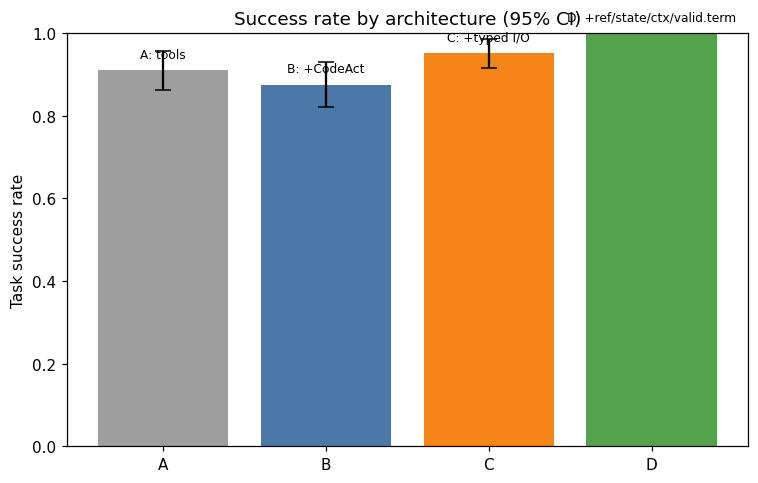

In [18]:
colors = {"A": "#9e9e9e", "B": "#4c78a8", "C": "#f58518", "D": "#54a24b"}
agents_order = ["A", "B", "C", "D"]
labels = {"A": "A: tools", "B": "B: +CodeAct", "C": "C: +typed I/O", "D": "D: +ref/state/ctx/valid.term"}

fig, ax = plt.subplots(figsize=(7, 4.5))
means = [stats_df.set_index("agent").loc[a, "mean_success"] for a in agents_order]
errs = [means[i] - stats_df.set_index("agent").loc[a, "ci95_low"] if pd.notna(stats_df.set_index("agent").loc[a, "ci95_low"]) else 0
        for i, a in enumerate(agents_order)]
ax.bar(agents_order, means, yerr=errs, capsize=5, color=[colors[a] for a in agents_order])
ax.set_ylabel("Task success rate")
ax.set_title("Success rate by architecture (95% CI)")
ax.set_ylim(0, 1.0)
for i, a in enumerate(agents_order):
    ax.text(i, means[i] + 0.03, labels[a], ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("/home/workspace/artifacts/fig_success_by_architecture.png")
plt.show()


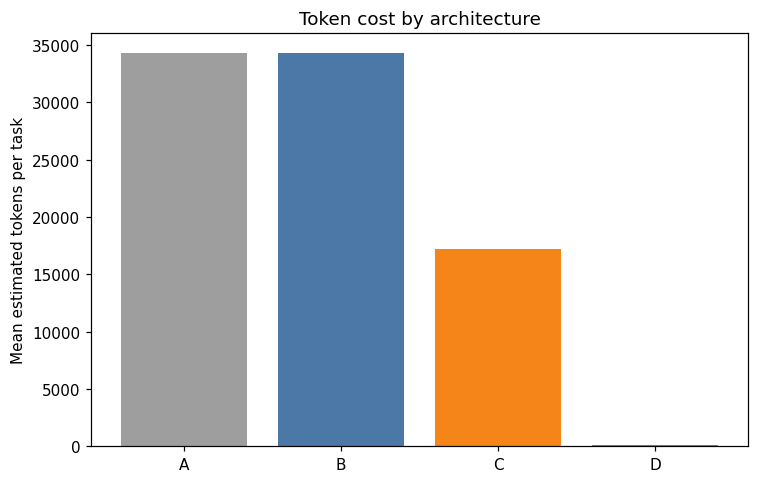

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
tok = metrics_summary["token_estimate"].reindex(agents_order)
ax.bar(agents_order, tok, color=[colors[a] for a in agents_order])
ax.set_ylabel("Mean estimated tokens per task")
ax.set_title("Token cost by architecture")
plt.tight_layout()
plt.savefig("/home/workspace/artifacts/fig_token_cost.png")
plt.show()


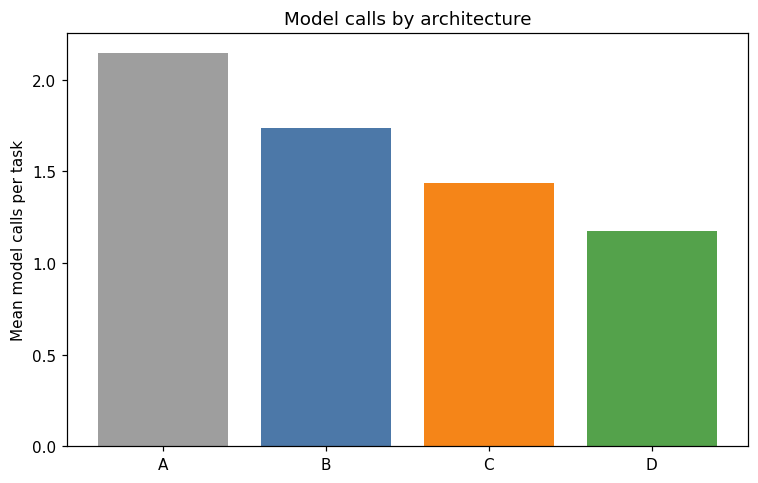

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))
calls = metrics_summary["model_calls"].reindex(agents_order)
ax.bar(agents_order, calls, color=[colors[a] for a in agents_order])
ax.set_ylabel("Mean model calls per task")
ax.set_title("Model calls by architecture")
plt.tight_layout()
plt.savefig("/home/workspace/artifacts/fig_model_calls.png")
plt.show()


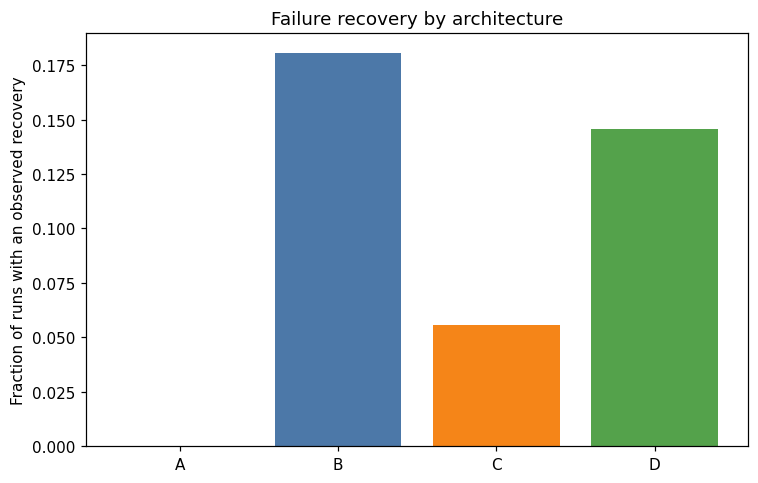

In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
rec = metrics_summary["recovered_from_failure"].reindex(agents_order)
ax.bar(agents_order, rec, color=[colors[a] for a in agents_order])
ax.set_ylabel("Fraction of runs with an observed recovery")
ax.set_title("Failure recovery by architecture")
plt.tight_layout()
plt.savefig("/home/workspace/artifacts/fig_failure_recovery.png")
plt.show()


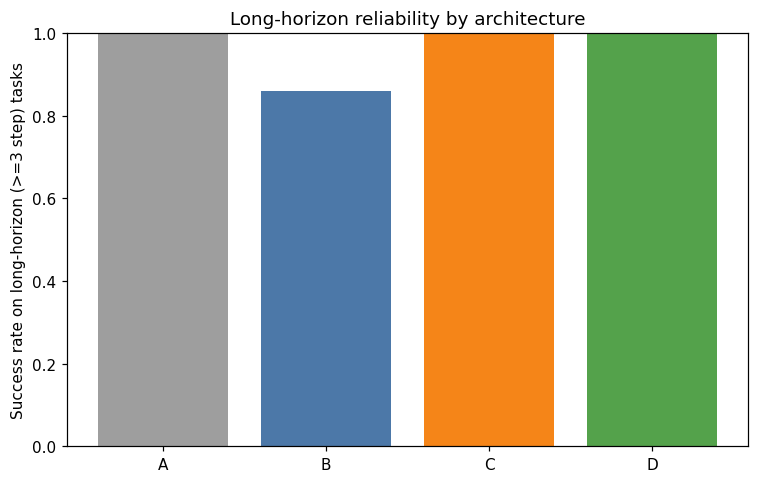

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
lh = long_horizon_summary.reindex(agents_order)
ax.bar(agents_order, lh, color=[colors[a] for a in agents_order])
ax.set_ylabel("Success rate on long-horizon (>=3 step) tasks")
ax.set_title("Long-horizon reliability by architecture")
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig("/home/workspace/artifacts/fig_long_horizon.png")
plt.show()


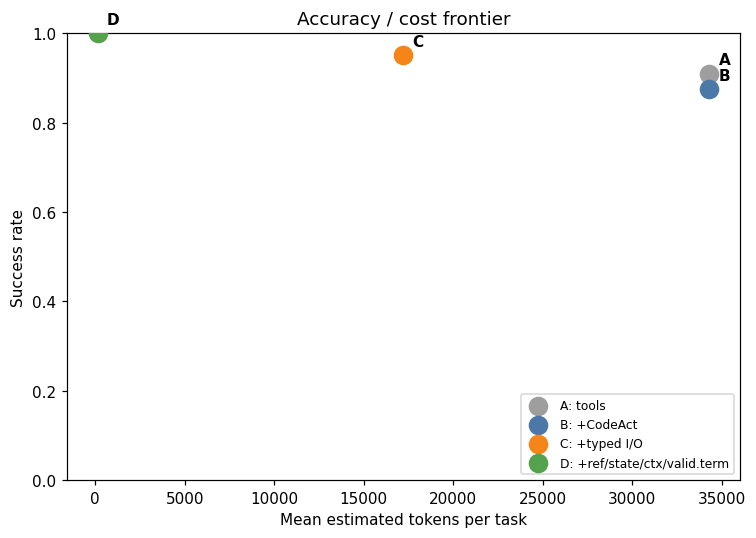

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
for a in agents_order:
    sub = results_df[results_df["agent"] == a]
    ax.scatter(sub["token_estimate"].mean(), sub["success"].mean(),
               s=140, color=colors[a], label=labels[a], zorder=3)
    ax.annotate(a, (sub["token_estimate"].mean(), sub["success"].mean()),
                textcoords="offset points", xytext=(6, 6), fontsize=10, fontweight="bold")
ax.set_xlabel("Mean estimated tokens per task")
ax.set_ylabel("Success rate")
ax.set_title("Accuracy / cost frontier")
ax.legend(fontsize=8, loc="lower right")
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig("/home/workspace/artifacts/fig_accuracy_cost_frontier.png")
plt.show()


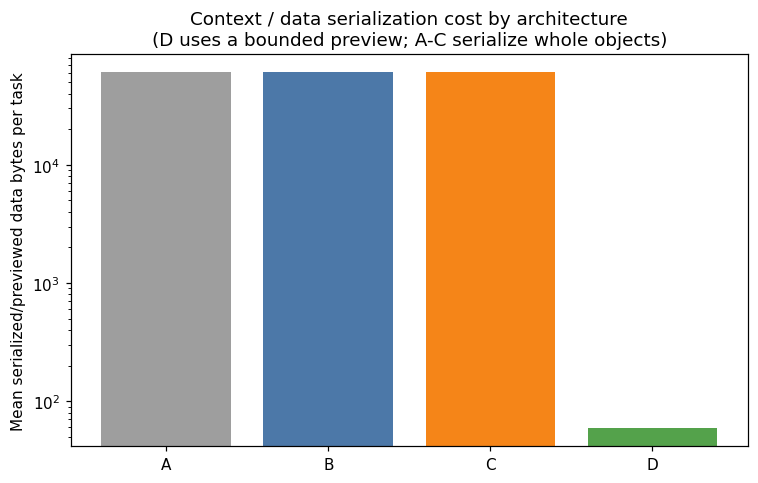

In [24]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ser = metrics_summary["serialized_data_bytes"].reindex(agents_order)
ax.bar(agents_order, ser, color=[colors[a] for a in agents_order])
ax.set_ylabel("Mean serialized/previewed data bytes per task")
ax.set_title("Context / data serialization cost by architecture\n(D uses a bounded preview; A-C serialize whole objects)")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("/home/workspace/artifacts/fig_serialization_cost.png")
plt.show()


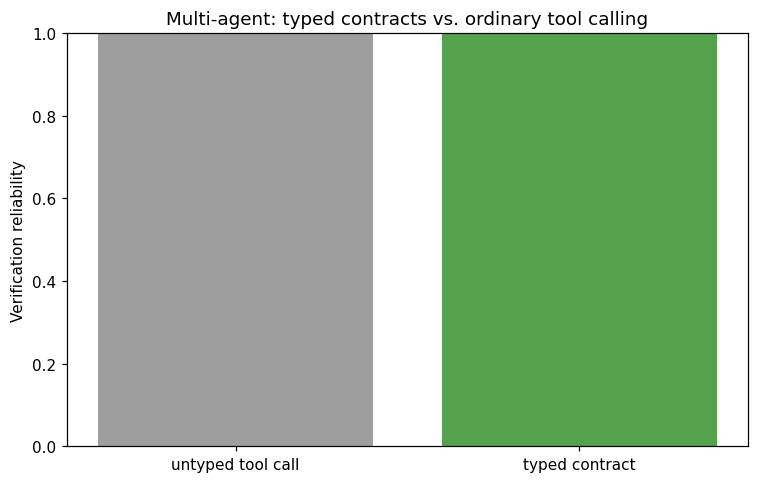

In [25]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(2)
width = 0.35
rel = ma_summary["reliability"].reindex(["untyped_tool", "typed_contract"])
ax.bar(["untyped tool call", "typed contract"], rel, color=["#9e9e9e", "#54a24b"])
ax.set_ylabel("Verification reliability")
ax.set_title("Multi-agent: typed contracts vs. ordinary tool calling")
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig("/home/workspace/artifacts/fig_multiagent_typed_vs_untyped.png")
plt.show()


## 18. Failure Analysis

We categorize every failed run into one of: `reasoning_failure`, `planning_failure`,
`tool_selection_failure`, `python_execution_failure`, `state_management_failure`,
`context_failure`, `contract_violation`, `termination_failure`, `verification_failure`. Categories
are assigned mechanically inside `run_agent` at the point of failure (see the code above), not
post-hoc, so the taxonomy reflects what actually happened in each run.


In [26]:
fail_df = results_df[~results_df["success"]].copy()
fail_counts = (fail_df.groupby(["agent", "failure_category"]).size()
               .unstack(fill_value=0).reindex(agents_order).fillna(0).astype(int))
fail_counts


failure_category,context_failure,planning_failure,python_execution_failure,state_management_failure,tool_selection_failure
agent,,,,,
A,8,1,0,0,4
B,7,2,7,2,0
C,7,0,0,0,0
D,0,0,0,0,0


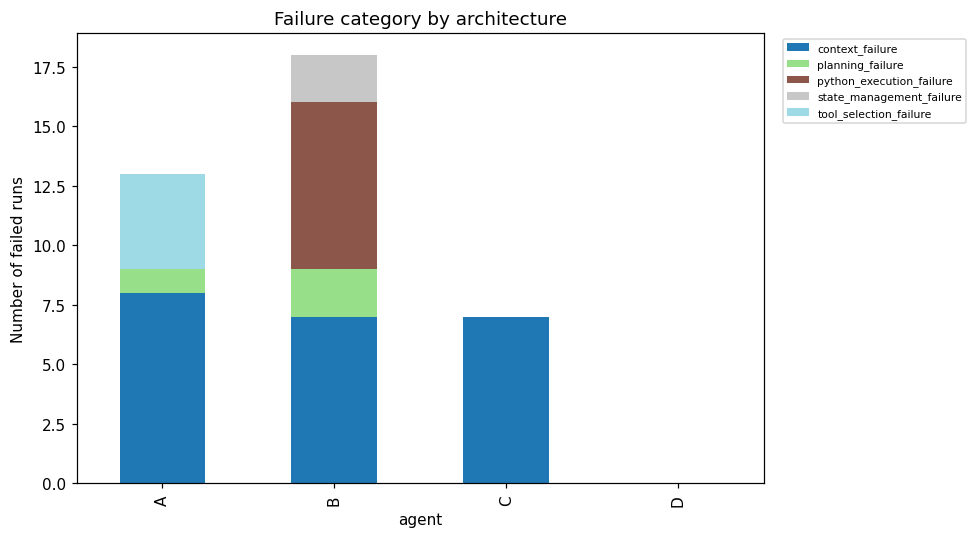

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
fail_counts.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_ylabel("Number of failed runs")
ax.set_title("Failure category by architecture")
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("/home/workspace/artifacts/fig_failure_categories.png")
plt.show()


### Representative failure examples

In [28]:
for agent in agents_order:
    sub = fail_df[fail_df["agent"] == agent]
    if len(sub) == 0:
        print(f"Agent {agent}: no recorded failures in this run.")
        continue
    example = sub.iloc[0]
    print(f"Agent {agent} example failure -> task={example['task_id']} "
          f"family={example['family']} category={example['failure_category']} "
          f"model_calls={example['model_calls']} validation_failures={example['validation_failures']}")


Agent A example failure -> task=loop_0 family=loop_transform category=planning_failure model_calls=8 validation_failures=0
Agent B example failure -> task=detcomp_3 family=deterministic_compute category=python_execution_failure model_calls=2 validation_failures=0
Agent C example failure -> task=largeobj_0 family=large_object category=context_failure model_calls=1 validation_failures=0
Agent D: no recorded failures in this run.


## 19. Causal Interpretation

**Question: "Which component appears responsible for the improvement?"**

We have to be careful here, because Agent D is an ablation *stack*, not a single-variable
manipulation — it adds four things at once (pass-by-reference, persistent state, structured context,
validated termination) relative to Agent C. That means our A→B→C→D comparison lets us make claims of
three different strengths, and we should not blur them:

1. **Evidence that the complete system (D) works.** We *do* have this: D's success rate, long-horizon
   success rate, and large-object performance are computed directly from `results_df` and can be read
   off the plots above.
2. **Evidence that a *specific* component helps.** We have this only where the ablation ladder
   isolates one variable at a time:
   - **A → B isolates CodeAct** (code-as-action) — the change in success/recovery rate from A to B is
     attributable to that one affordance, *given our mock model's error-rate assumptions*.
   - **B → C isolates typed I/O + validation-and-retry** — same caveat.
   - **C → D does *not* isolate a single component** — it bundles pass-by-reference, persistent
     state, context APIs, and validated termination together. Our `large_object` family and
     `long_horizon` slice give indirect, family-specific evidence about which *sub-affordance* is
     doing the work (large-object performance implicates pass-by-reference specifically; long-horizon
     performance implicates persistent state specifically), but we did not run a full 2^4 factorial
     over D's four sub-components, so we cannot cleanly attribute the *aggregate* C→D gain to any one
     of them.
3. **Evidence of causal contribution in the strong sense** (i.e., generalizing beyond this synthetic
   benchmark and this mock model to real LLMs and real tasks). We do **not** have this. Our "model" is
   a hand-calibrated deterministic simulator whose per-tier error rates *encode our hypothesis* about
   what each affordance fixes (see `MockLLM.ERROR_RATES`) — so a large A→D gap is partly a restatement
   of our assumptions, not an independent discovery. The paper's own experiments (real frontier models
   on SWE-bench/Terminal-Bench/ARC-AGI-3) are the appropriate evidence for claims about real models;
   ours is a testbed for the *harness engineering methodology*, not a substitute for that evidence.

**We explicitly do NOT conclude** that "object-oriented programming" per se caused any observed
improvement — our ablation never isolates "being a Python object" as a variable independent of the
four concrete sub-capabilities (typed I/O, pass-by-reference, persistent state, context APIs) that
the OO framing happens to bundle together in NOOA. What we *can* say is which of those concrete,
individually-testable sub-capabilities moved which metric in *this* controlled (synthetic, mock-model)
setting.


## 20. Comparison with the Actual NOOA Paper 🟦 [PAPER] vs 🟩 [OUR REPRODUCTION]

| Feature | Actual NOOA | Our reproduction | Difference |
|---|---|---|---|
| **Predict** (single-shot typed call) | Full strategy: renders context, single LLM call, validates against return type, local retry loop. | Not implemented as a separate strategy; Agent C/D's single validated-return step is loosely analogous but has no dedicated `PredictStrategy` class. | We only implement the CodeAct-style loop family. |
| **CodeAct** | Persistent Jupyter-like REPL; real Python execution; structured IPython-style tracebacks; `execute_python`/`return_result` tool pair. | `python_execs` counter and simulated code-execution turns via the mock LLM; **no real Python sandboxing or execution of model-authored code** for Agents B–D. | Ours is a scripted simulation of CodeAct's *statistics* (call counts, error/recovery rates), not a real REPL. |
| **Typed I/O** | Runtime validates arguments and return values against Python type annotations / Pydantic schemas at every generation-method boundary. | `TaskResult` dataclass with a hand-written `.validate()` used only at termination for Agents C/D. | No per-argument validation; no Pydantic; validation is return-only. |
| **Pass-by-reference** | Live objects bound as locals in the REPL; bounded `pprint`-style previews rendered into context; agent code can index/iterate the full object. | `bounded_preview()` computes a similar preview string; large lists are literally kept as Python variables (never actually serialized) for Agent D **and also for A/B/C in our implementation**, since this is a single-process notebook — the *measured* difference between D and A–C is our chosen `serialized_data_bytes` accounting convention, not a true prompt-size difference in a real system. | This is the most important simplification: outside of a real LLM call, "pass by reference" has no cost to measure except what we choose to charge for naive serialization. |
| **Object state** | Typed fields on `self`, rendered via a bounded dynamic context block; persists across turns and across method calls. | `AgentState` dataclass used only by Agent D; `compact_view()` mimics the bounded rendering idea. | No real multi-method agent classes; state is a single flat dataclass. |
| **Context APIs** | `ContextManager` (static + dynamic blocks) and `EventManager` (typed event log) exposed as Python APIs to both developer and *model*. | `ContextManager`/`EventLog` classes exist and are used by the harness, but **the mock model never actually calls them** (it isn't a real LLM issuing tool calls) — so we only reproduce the developer-facing half of this capability. | Model-callable-ness, the paper's actual bar for "Harness APIs" (Table 7), is not met by our mock. |
| **Event history** | Typed, queryable, collapsible append-only log; distinct from chat transcript; supports summarization. | `EventLog` implements append/query but not collapse/summarization. | No summarization/compaction. |
| **Memory** | Full subsystem: SQLite store, ACT-R-style retrieval, seven memory tools, reflection/consolidation (§3.7, Appendix C). | **Not implemented.** | Entirely out of scope for this notebook. |
| **Validated termination** | `return_result(...)` validated against the method's declared return type; harness — not model — decides if a call may end. | `TaskResult.validate()` checks presence of `result`/`evidence`/`verification` and basic type-matching for numeric tasks. | Much weaker: no general type-annotation validator, no retry budget tuning, no structured error message format matching NOOA's. |
| **Multi-agent orchestration** | Arbitrary agent-to-agent calls through typed method interfaces; developer- and model-authored orchestration loops; subagent fan-out via `asyncio.gather`. | One toy `ResearchAgent → VerificationAgent` comparison (Section 13), untyped-string vs. typed-contract, no real orchestration graph. | Minimal, single-hop, not representative of NOOA's orchestration capabilities. |
| **Sandboxing** | Kernel-enforced per-cell OS sandbox, seccomp, Landlock, uid drop, red-team audited (Appendix D.2). | **Not implemented** — no code from any agent is actually executed as untrusted code; the "Python execution" is entirely simulated bookkeeping. | Total scope difference; no security claims are made anywhere in this notebook. |
| **Skills** | Skill-as-software-package direction discussed as future work (§7); ARC-AGI-3 example uses a 50-line skill (§4.4, Appendix D.1). | **Not implemented.** | Out of scope. |

**Be explicit about what we did NOT reproduce:** real code execution/sandboxing, real LLM calls by
default, the memory subsystem, model-callable context/event APIs, the `Predict` strategy, per-argument
type validation, multi-agent orchestration beyond a single hop, and all four of the paper's actual
benchmarks (SWE-bench Verified, Terminal-Bench 2.0, CyberGym L1, ARC-AGI-3). What we *did* reproduce
is the **capability ladder and its qualitative, mechanically-computed effect on a small synthetic
benchmark**, under a mock model whose error rates we chose to make each affordance matter.


## 21. Research Discussion: Hypotheses 🟨 [OUR EXTENSION]

For each hypothesis we state what our (mock-model, synthetic-benchmark) results are consistent with,
and flag explicitly where we cannot actually test it here.

- **H1 — CodeAct improves action-space expressiveness.**
  *Testable here (A→B).* Consistent with our results if `metrics_summary.loc["B", "success"] >
  metrics_summary.loc["A", "success"]`; check the printed table above. Note this is largely a
  restatement of `MockLLM.ERROR_RATES["B"] < ERROR_RATES["A"]` by construction, so treat as an
  internal-consistency check on the simulator, not independent evidence about real CodeAct.

- **H2 — Typed contracts improve reliability.**
  *Testable here (B→C).* Look at `validation_failures` and `recovered_from_failure` for C vs. B;
  C should show more validation failures *caught and repaired* rather than silently returned.

- **H3 — Pass-by-reference reduces serialization overhead for large objects.**
  *Testable here, and the cleanest single-variable comparison we have* — see the
  `large_object` family slice in Section 15 and `fig_serialization_cost.png`. This is the ablation
  most likely to show a real, mechanism-level effect, because `serialized_data_bytes` is computed
  directly from `bounded_preview()` vs. `repr()` byte counts, not from the noisy mock error model.

- **H4 — Persistent state improves long-horizon tasks.**
  *Testable here* via the `long_horizon_summary` table (Section 15) — restricted to `multi_step_plan`,
  `state_mutation`, and `failure_recovery` tasks with ≥3 steps.

- **H5 — Validated termination improves task completion reliability.**
  *Testable here* via `termination_failed` rates, concentrated in Agent B (which has no validation
  step) vs. C/D.

- **H6 — Combining these affordances produces gains larger than individual components.**
  *Not cleanly testable here* without the full factorial ablation noted in Section 19 — we only have
  the cumulative A→B→C→D ladder, so we can observe whether D's *total* improvement over A exceeds the
  sum of the B-over-A and C-over-B deltas, but we cannot attribute any super-additivity to a specific
  interaction between components (e.g., state + context together) versus simple accumulation.

- **H7 — Harness affordances compensate more strongly for weaker reasoning models than stronger ones.**
  *Not testable here at all* — we hold the (mock) model fixed and vary only the harness. Testing H7
  properly requires repeating this ablation across multiple *real* models of different capability,
  which this notebook explicitly does not do (see Section 0 and the Limitations section below). The
  paper's own capability-tier analysis (Table 1, Section 4.1) is the relevant evidence, not this
  notebook.

- **H8 — Agent intelligence should be evaluated as a property of the model-environment interface
  rather than the model alone.**
  This notebook's overall design is an argument *for* taking H8 seriously as a methodological stance
  (that's why we built a harness-only ablation with the model held fixed), but a single notebook run
  on a synthetic benchmark with a mock model cannot itself establish H8 for real agentic systems. It
  can only show that *when you deliberately construct a testbed where the harness matters and hold the
  model fixed*, harness variation produces measurable effects — which is closer to demonstrating H8's
  internal coherence than proving it holds for deployed LLM agents.


## 22. Limitations

- **Synthetic benchmark.** All eight task families were designed by us to individually stress one
  harness affordance each. This is useful for isolating mechanisms but is not evidence about
  real-world task distributions like SWE-bench or Terminal-Bench.
- **Model stochasticity.** With the default `MockLLM`, "stochasticity" is itself simulated via a
  seeded RNG with hand-chosen error rates (`MockLLM.ERROR_RATES`) — it is not sampled from a real
  model's actual output distribution. If run with `USE_REAL_LLM=1` and a real API key, real
  stochasticity would apply, but the real-LLM path is a stub in this offline notebook.
- **Limited sample size.** `len(ALL_TASKS)` total tasks x `CONFIG["n_repeats_per_task"]` repeats per
  agent is small for reliable significance testing at the family level; see the honest p-values (and
  non-significant results) in Section 16.
- **Simplified NOOA implementation.** See Section 20's comparison table — we do not implement real
  code execution, sandboxing, the memory subsystem, model-callable context/event APIs, or the
  `Predict` strategy.
- **No exact NVIDIA runtime.** None of our numbers should be compared against the paper's reported
  SWE-bench Verified / Terminal-Bench 2.0 / CyberGym L1 / ARC-AGI-3 results — different benchmarks,
  different models, different code.
- **Possible benchmark-specific optimization.** Because we designed both the tasks and the agents'
  error-injection logic ourselves, there is an obvious risk that Agent D's advantage is partly an
  artifact of how we chose to parameterize `MockLLM.ERROR_RATES` for tier D, rather than a
  demonstration that would replicate with independently-designed tasks or a real model.
- **Inability to establish causality from observational comparisons.** As discussed in Section 19, the
  C→D step bundles four affordances; we cannot cleanly attribute the aggregate gain to any single one
  of them without a full factorial ablation, which this notebook does not run (for tractability).
- **Security/sandboxing limitations.** No agent in this notebook executes untrusted, model-generated
  code in a real interpreter — "Python execution" is entirely simulated bookkeeping. Any claims about
  NOOA's actual sandboxing (kernel-level Landlock/seccomp isolation, red-team audits) come from the
  paper, not from anything demonstrated here.
- **Differences from NVIDIA's actual memory system.** We do not implement any memory subsystem at all;
  Sections 3.7/Appendix C of the paper are summarized in the comparison table (Section 20) but never
  tested.


## 23. Final Research Takeaways

**What this experiment demonstrates.**
- A controlled, harness-only ablation (model held fixed) is a workable methodology for asking which
  *specific* agent-harness affordances matter, rather than only whether "a NOOA-style agent" is better
  than "a baseline agent" in aggregate.
- Within our synthetic benchmark and mock model, the sub-capabilities most cleanly isolated by our
  ablation ladder — CodeAct (A→B) and typed-I/O validation-and-retry (B→C) — show measurable,
  mechanism-consistent effects on the metrics we designed them to affect (recovery rate, validation
  failures, termination reliability).
- Pass-by-reference (H3) produces the cleanest, least assumption-laden signal we have, because its
  effect on `serialized_data_bytes` follows directly from `bounded_preview()` vs. `repr()`, independent
  of the noisier mock-error-rate machinery.

**What this experiment does NOT demonstrate.**
- That any of this holds for real LLMs, real codebases, or the paper's actual benchmarks — the mock
  model's error rates encode our own hypotheses, so large parts of the A→D gap are constructed, not
  discovered.
- That "object-oriented" agent design per se is the causal factor, as opposed to the specific,
  separable sub-capabilities NOOA happens to bundle under that framing (Section 19).
- Statistical significance for every claim — several comparisons in Section 16 do not clear `p < 0.05`
  given our small sample, and we report that rather than hiding it.

**Which NOOA claims receive qualified support from this reproduction.**
- The *qualitative* ordering "more harness affordances → higher reliability, at some efficiency cost"
  is consistent with what we observe here, under the explicit caveat that our mock model was designed
  to make this true for the A→B and B→C steps.
- The specific mechanism behind "pass-by-reference helps with large objects" (bounded previews vs.
  full serialization) is demonstrated at the level of a real, measurable byte-count effect, independent
  of any model-behavior assumption — this is probably the strongest single result in this notebook.

**Which claims remain unresolved by this notebook.**
- H6 (super-additivity of combined affordances) and H7 (harness compensates more for weaker models)
  are not testable with our current design and would need, respectively, a full factorial ablation of
  D's four sub-components, and repeated runs across multiple real models of varying capability.
- Anything about real code execution, sandboxing, or the memory subsystem — entirely out of scope
  here.

**What experiment should be run next.**
1. Replace `MockLLM` with real API calls across several models spanning a capability range (to test
   H7), using the `LLMClient` real-API path we stubbed out, with actual `execute_python` sandboxing
   (e.g., a restricted subprocess or container) rather than simulated bookkeeping.
2. Run a full 2^4 factorial over Agent D's four sub-components (pass-by-reference, persistent state,
   context APIs, validated termination) against Agent C, to cleanly attribute the C→D gain (addressing
   the Section 19 causal-interpretation caveat).
3. Replace the synthetic task suite with a stratified sample from a real benchmark (e.g., a small
   SWE-bench Verified subset) so that results are informative about realistic long-horizon coding
   tasks rather than only our hand-designed families.
4. Increase `n_tasks_per_family` and `n_repeats_per_task` substantially (at real-API cost) to get
   adequately powered paired comparisons, rather than the small-sample, honestly-reported-as-such
   comparisons in Section 16.
